# Predicting Profitability in Logistics Operations Using ML

**Author:** Maryi Tatiana Palacios Giraldo  
**Course:** MSDS692_S40_Data Science Practicum

## Data Understanding

The dataset consists of import shipment records from a customs brokerage company. These records represent logistics operations, combining shipment tracking, financial performance, and operational metrics across multiple transport modes, including air, sea, and land.

The dataset contains 8,270 rows and 49 columns with detailed information on shipping routes, time-related variables (such as ETD, ETA, and ATA), financial indicators (including revenue, cost, and profit), and cargo characteristics such as weight, volume, and TEU. Additionally, it contains variables related to key entities involved in the process, such as suppliers, importers, and clients, providing a comprehensive view of the shipment lifecycle.

All information is handled with strict confidentiality and is used solely for academic purposes. No personal or sensitive client information is disclosed, and all results are presented at an aggregated level to ensure data privacy.

### Objective of the project

The objective of this project is to predict whether a shipment will be profitable using operational and shipment-level features available before execution.

In [291]:
import pandas as pd
import matplotlib.pyplot as plt

In [292]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [293]:
df = pd.read_excel(r'C:\Users\tatiana.palacios\OneDrive - Gallagher Transport International\Documents\Tatiana\My docs\Practicum\Dataset\declaration.xlsx')

In [294]:
print(df.head())

  Declaration ID Cancel Trans Dec. Type Mode   Br Standalone  # Inv. Headers  \
0      B00001490      N   AIR       IMP  NCT  DEN          Y               1   
1      B00001491      N   TRK       IMP  NCT  SFO          Y               1   
2      B00001492      N   NaN       EXP  NaN  SFO          Y               0   
3      B00001493      N   SEA       IMP  CNT  IAH          Y               1   
4      B00001494      N   SEA       IMP  NCT  IAH          Y               1   

   # Inv. Lines Origin  ...          Job Opened  Revenue   WIP Total Income  \
0             1  CHBSL  ... 2025-12-01 15:13:00   235.00   NaN       235.00   
1             1  JPTYO  ... 2025-12-01 15:15:00      NaN   NaN          NaN   
2             0    NaN  ... 2025-12-01 15:16:00      NaN  3.28         3.28   
3             1  AOLAD  ... 2025-12-01 15:18:00   751.52   NaN       751.52   
4             1  BRSAO  ... 2025-12-01 16:01:00  1214.06   NaN      1214.06   

     Cost Accrual Total Expense Job Profit C

In [295]:
df.tail()

,Declaration ID,Cancel,Trans,Dec. Type,Mode,Br,Standalone,# Inv. Headers,# Inv. Lines,Origin,...,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
8265,S00001288,N,AIR,EXP,NCT,DEN,N,1,1,USPE4,...,2026-04-17 18:35:00,770.0,8.35,778.35,-356.35,NaN,-356.35,422.00,0,0.0
8266,S00001290,N,ROA,EXP,NaN,DEN,N,1,1,USBUF,...,2026-04-29 16:59:00,165.0,NaN,165.00,-8.35,NaN,-8.35,156.65,0,0.0
8267,S00001293,N,TRK,EXP,NCT,DEN,N,1,1,USPHN,...,2026-05-15 15:39:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
8268,S00001294,N,SEA,EXP,CNT,DEN,N,1,1,USHOU,...,2026-05-18 16:07:00,200.0,NaN,200.00,-12.75,NaN,-12.75,187.25,1,2.3
8269,S00001298,N,SEA,EXP,CNT,DEN,N,1,1,USOLS,...,2026-05-28 18:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0


In [296]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8270 entries, 0 to 8269
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Declaration ID     8270 non-null   str           
 1   Cancel             8270 non-null   str           
 2   Trans              7875 non-null   str           
 3   Dec. Type          8270 non-null   str           
 4   Mode               7824 non-null   str           
 5   Br                 8270 non-null   str           
 6   Standalone         8270 non-null   str           
 7   # Inv. Headers     8270 non-null   int64         
 8   # Inv. Lines       8270 non-null   int64         
 9   Origin             7804 non-null   str           
 10  Final Dest.        7920 non-null   str           
 11  Load               7793 non-null   str           
 12  Arrival            7941 non-null   str           
 13  Origin ETD         6649 non-null   datetime64[us]
 14  Dest. ETA          

The dataset contains 8,270 records and 49 columns, with 14 numeric variables, 6 date fields, and 29 categorical ones. Variables such as WIP, Accrual, Job Sales Rep, and House have significant missing values (40–85%), limiting their usability. Additionally, some logistical tracking fields (e.g., ETD/ETA dates) show moderate gaps that I will be reviewing in the cleanning process.

In [297]:
df.describe()

,# Inv. Headers,# Inv. Lines,Origin ETD,Dest. ETA,Load ATD,Arrival ATA,Dec. Registered,Weight,Volume,Packs,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
count,8270.000000,8270.000000,6649,7613,7658,7653,8270,8270.000000,8270.000000,8270.00000,8270,6948.000000,1292.000000,8204.000000,8158.000000,1036.000000,8203.000000,8264.000000,8270.000000,8270.000000
mean,0.927207,8.696372,2026-02-16 13:12:42.538727,2026-03-12 20:36:19.048995,2026-02-15 07:01:23.677200,2026-03-10 09:36:09.031752,2026-02-25 22:33:59.354292,9849.974870,24.667200,346.56058,2026-02-25 21:45:10.251511,5966.974290,3002.420139,5526.287688,-4768.599712,-4505.491467,-5311.462344,213.908347,0.462273,0.715175
min,0.000000,0.000000,2020-01-22 00:00:00,2025-04-24 00:00:00,2025-01-25 00:00:00,2025-04-21 00:00:00,2025-12-01 14:28:00,0.000000,0.000000,0.00000,2025-10-30 17:08:00,30.000000,1.150000,3.280000,-215878.690000,-103629.810000,-216162.050000,-8642.950000,0.000000,0.000000
25%,1.000000,1.000000,2026-01-02 00:00:00,2026-01-22 00:00:00,2025-12-29 06:00:00,2026-01-20 00:00:00,2026-01-08 23:15:00,168.000000,0.000000,1.00000,2026-01-08 22:19:15,270.000000,9.950000,183.580000,-4378.920000,-7797.672500,-6899.800000,107.050000,0.000000,0.000000
50%,1.000000,1.000000,2026-02-17 00:00:00,2026-03-11 00:00:00,2026-02-14 00:00:00,2026-03-09 00:00:00,2026-02-24 23:40:30,1510.000000,0.000000,6.00000,2026-02-24 23:13:00,899.510000,9.950000,746.500000,-270.010000,-400.000000,-482.790000,150.000000,0.000000,0.000000
75%,1.000000,1.000000,2026-04-07 00:00:00,2026-05-01 00:00:00,2026-04-06 00:00:00,2026-04-29 00:00:00,2026-04-14 21:44:00,13525.500000,0.000000,128.00000,2026-04-14 21:35:15,7015.440000,7000.240000,7033.100000,-9.950000,-110.500000,-9.950000,253.000000,1.000000,1.000000
max,31.000000,9956.000000,2026-12-12 00:00:00,2028-04-29 00:00:00,2026-07-19 00:00:00,2026-08-23 00:00:00,2026-05-30 14:43:00,999999.999000,120000.000000,83457.00000,2026-05-30 14:43:00,216592.410000,88476.740000,216592.410000,5531.160000,15032.400000,0.020000,5211.040000,23.000000,52.000000
std,1.046285,183.019364,NaN,NaN,NaN,NaN,NaN,40497.682726,1360.841362,2478.98673,NaN,14027.022707,6446.257385,13200.980621,12929.197868,8368.710780,13119.693279,343.426552,0.885768,1.758033


In [298]:
df.columns

Index(['Declaration ID', 'Cancel', 'Trans', 'Dec. Type', 'Mode', 'Br',
       'Standalone', '# Inv. Headers', '# Inv. Lines', 'Origin', 'Final Dest.',
       'Load', 'Arrival', 'Origin ETD', 'Dest. ETA', 'Load ATD', 'Arrival ATA',
       'Dec. Registered', 'Supplier', 'Supplier Name', 'Importer',
       'Importer Name', 'House', 'Master', 'Vessel', 'Voy./Flt.', 'Weight',
       'Wt. UQ', 'Volume', 'Vol. UQ', 'Packs', 'Pack Type', 'BR', 'Dept',
       'Local Client', 'Local Client Name', 'Job Sales Rep', 'Job Operator',
       'Status', 'Job Opened', 'Revenue', 'WIP', 'Total Income', 'Cost',
       'Accrual', 'Total Expense', 'Job Profit', 'Ctr Count', 'TEU'],
      dtype='str')

In [299]:
df.duplicated().sum()

np.int64(0)

In [300]:
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_pct.sort_values(ascending=False)

Accrual              87.472793
WIP                  84.377267
House                51.692866
Job Sales Rep        49.830713
Vessel               39.842805
Origin ETD           19.600967
Revenue              15.985490
Pack Type            13.518742
Voy./Flt.            11.995163
Vol. UQ               9.600967
Dest. ETA             7.944377
Arrival ATA           7.460701
Load ATD              7.400242
Master                6.372430
Load                  5.767836
Supplier              5.719468
Supplier Name         5.719468
Origin                5.634825
Mode                  5.392987
Trans                 4.776300
Final Dest.           4.232164
Arrival               3.978235
Importer              3.446191
Importer Name         3.446191
Wt. UQ                2.406288
Cost                  1.354293
Total Expense         0.810157
Total Income          0.798065
Local Client          0.133011
Local Client Name     0.133011
Job Profit            0.072551
Declaration ID        0.000000
# Inv. L

Most operational variables show very low missing rates (<1%), indicating that core shipment information is consistently capture.

# Handling missing values

## Remove columns with a high number of missing values:

In [301]:
cols_drop = [
    'WIP', 'Accrual', 'House',
    'Job Sales Rep', 'Vessel',
    'Master', 'Vol. UQ', 'Voy./Flt.'
]

df = df.drop(columns=cols_drop)

Variables with extremely high missing rates or low analytical value were removed to improve data quality and reduce noise:

- WIP and Accrual: mostly missing (>85%), not reliable for modeling
- House, Master, Vessel, Voy./Flt. and Vol. UQ: not very relevant for the analysis

## Handling Categorical Variables with Unknown

In [302]:
cat_cols = [
    'Mode', 'Origin', 'Final Dest.', 'Supplier', 'Supplier Name',
    'Importer', 'Importer Name', 'Pack Type', 'Load', 'Local Client' , 'Local Client Name' ,
    'Wt. UQ', 'Trans', 'Arrival'
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

Categorical variables were imputed using a placeholder value "Unknown":

- Preserves information about missing categories
- Prevents loss of records
- Standard practice for categorical imputation in logistics datasets

## Numerical variables with the mean

In [303]:
numeric_cols = ['Revenue', 'Cost', 'Total Expense', 'Total Income', 'Job Profit']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

Financial variables were imputed using the median to reduce the impact of outliers:

- Median is robust to extreme values (important due to high variance in revenue/cost)
- Maintains distribution integrity


In [304]:
df = df.dropna(subset=['Arrival ATA'])

Additionally, the Arrival ATA variable had very few missing values and was handled by removing incomplete records.

## Date Variables: Adjust Format

In [305]:

date_cols = [
    'Origin ETD', 'Dest. ETA',
    'Load ATD', 'Arrival ATA',
    'Dec. Registered', 'Job Opened'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [306]:

df['Origin ETD'] = df['Origin ETD'].fillna(df['Load ATD'])
df['Dest. ETA'] = df['Dest. ETA'].fillna(df['Arrival ATA'])


Missing date values were handled using logical imputation. For example, when the estimated departure date (ETD) was missing, it was replaced with the actual departure date (ATD), since both represent closely related shipment events. Similarly, missing estimated arrival dates (ETA) were replaced with actual arrival dates (ATA). This approach preserves temporal consistency while avoiding unnecessary data loss.

In [307]:
df.isnull().sum().sum()

np.int64(35)

In [308]:
cat_cols = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name',
    'Importer', 'Importer Name',
    'Pack Type',
    'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status',
    'Wt. UQ', 'Br',
]

In [309]:
for col in cat_cols:
    df[col] = df[col].astype('category')

Several variables originally stored as object type were identified as categorical variables representing discrete operational and logistical attributes within the shipment process. These include transportation mode, geographic origin and destination, suppliers, importers, operational status, and packaging types.

To support more effective exploratory analysis, these variables were converted to the category data type in pandas.

## Binary Variables

In [310]:
df['Cancel'] = df['Cancel'].map({'Y':1,'N':0})
df['Standalone'] = df['Standalone'].map({'Y':1,'N':0})

Converting to Categorical

In [311]:
cat_cols_final = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name', 'Importer', 'Importer Name',
    'Pack Type', 'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status', 'Wt. UQ', 'Br'
]

for col in cat_cols_final:
    if col in df.columns:
        df[col] = df[col].astype('category')

In addition to categorical transformations, binary variables were identified and encoded into numerical format to ensure compatibility with statistical analysis and potential predictive modeling tasks. Specifically, variables representing yes/no conditions were transformed into binary indicators.

In [312]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)



Origin ETD    17
Load ATD      18
dtype: int64


In [313]:
df_missing[[
    "Origin ETD",
    "Load ATD",
    "Dest. ETA",
    "Arrival ATA",
    "Status",
    "Transport Type"
]]

,Origin ETD,Load ATD,Dest. ETA,Arrival ATA,Status,Transport Type
1618,NaT,NaT,2026-01-01,2025-12-30,INV,SEA
1852,NaT,NaT,2025-12-31,2025-12-24,INV,AIR
2287,NaT,NaT,2026-01-15,2026-01-14,INV,AIR
4979,NaT,NaT,2026-03-04,2026-03-04,INV,AIR
4983,NaT,NaT,2026-03-04,2026-03-01,INV,AIR
5163,NaT,NaT,2026-03-28,2026-03-28,INV,SEA
5537,NaT,NaT,2026-04-02,2026-04-02,INV,SEA
6258,NaT,NaT,2026-05-01,2026-05-01,WRK,SEA
6341,NaT,NaT,2026-06-07,2026-06-07,WRK,SEA
6443,NaT,NaT,2026-06-03,2026-06-03,WRK,SEA


In [314]:
df = df.dropna(subset=["Origin ETD", "Load ATD"])


A very small number of records (less than 0.3% of the dataset) still contained missing values in departure variables (Origin ETD and Load ATD). After reviewing these cases, it was determined that they represent inconsistent or incomplete shipment records. Given their minimal proportion and lack of reliability, these observations were removed to ensure data consistency and maintain the integrity of the modeling process.


In [315]:
df = df.rename(columns={

    '# Inv. Headers': 'Invoice Headers',
    '# Inv. Lines': 'Invoice Lines',

    'Wt. UQ': 'Weight Unit',
    'Vol. UQ': 'Volume Unit',

    'Trans': 'Transport Type',
    'Mode': 'Mode',
    'Br': 'Branch',

    'Dec. Type': 'Dec. Type',

    'Arrival': 'Arrival Port',
    'Origin': 'Origin Port',
    'Final Dest.': 'Final Destination',
    'Load': 'Load Port',

    'Voy./Flt.': 'Voyage/Flight',

    'Ctr Count': 'Container Count',

    'Job Opened': 'Job Opened',
    'Job Operator': 'Job Operator',

    'Local Client': 'Local Client',
    'Local Client Name': 'Local Client Name',

    'Supplier': 'Supplier',
    'Supplier Name': 'Supplier Name',

    'Importer': 'Importer',
    'Importer Name': 'Importer Name'
})

Column names were selectively standardized to improve readability during analysis.

In [316]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)


Series([], dtype: int64)


The dataset has been successfully cleaned, structured, and transformed into an analysis-ready format. Variables were correctly assigned to categorical, numerical, binary, and datetime types based on their semantic meaning within the logistics domain. This ensures both computational efficiency and analytical interpretability, making the dataset suitable for exploratory data analysis and subsequent forecasting modeling.

# EDA


# 1. SHIPMENT CHARACTERISTICS

In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Declarations processed per month

In [318]:

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day


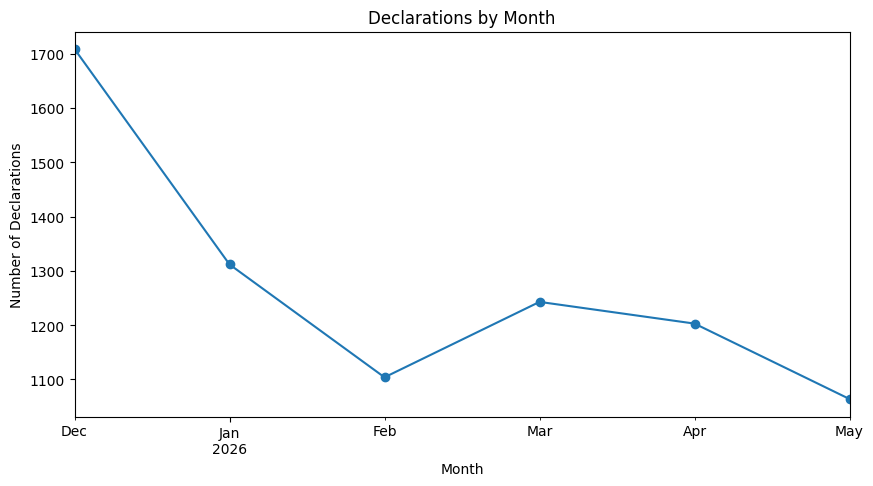

In [319]:
monthly_decl = df.groupby("reg_month").size()

monthly_decl.plot(marker="o", figsize=(10,5))
plt.title("Declarations by Month")
plt.ylabel("Number of Declarations")
plt.xlabel("Month")
plt.show()


This chart shows the number of declarations over time. We observe a peak in December, followed by a significant decline in early months, suggesting seasonal demand patterns. Although there is a partial recovery in March, the overall trend remains lower compared to the year-end peak.

## 1.2. Transport Type Distribution

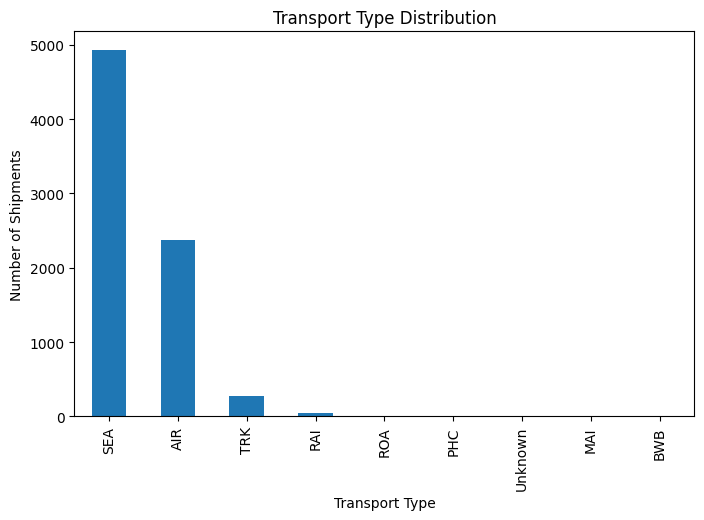

In [320]:
df["Transport Type"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Transport Type Distribution")
plt.ylabel("Number of Shipments")
plt.xlabel("Transport Type")
plt.show()


The transport type distribution shows a strong dominance of sea shipments, followed by air transport. Other modes contribute minimally to overall operations. This indicates a high dependency on specific transport types, which may introduce operational risks, particularly in modes prone to delays such as sea transport.

Transport Type Reference:

AIR – Air Transport  
SEA – Sea Transport  
TRK – Truck  
RAI – Rail  
ROA – Road  
MAI – Mail  
PHC – Hand Carry  

## 1.3. Branch Distribution

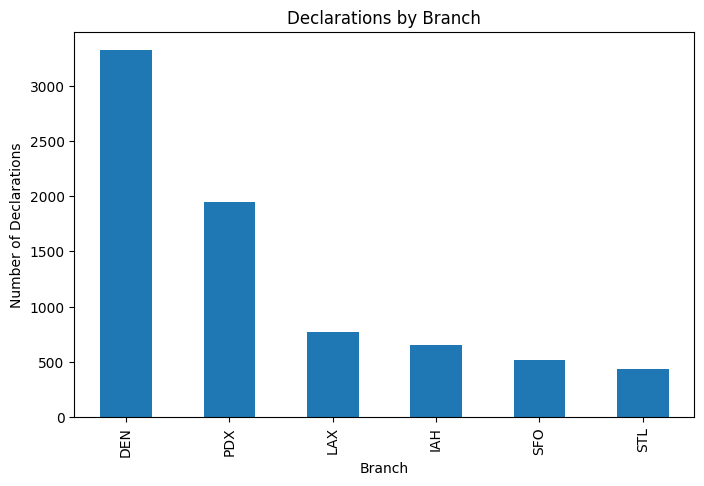

In [321]:
df["Branch"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Declarations by Branch")
plt.ylabel("Number of Declarations")
plt.show()

This chart shows the distribution of declarations across branches. The Denver branch dominates operations, handling a significantly higher volume than all other locations. Portland represents a secondary hub, while the remaining branches contribute at a much smaller scale. This concentration may introduce operational risk and makes overall performance highly dependent on a single branch.

Branch Reference:

DEN – Denver  
PDX – Portland  
LAX – Los Angeles  
IAH – Houston  
SFO – San Francisco  
STL – St. Louis  

# 2. PROFITABILITY ANALYSIS

## 2.1 Monthly Profit Trend

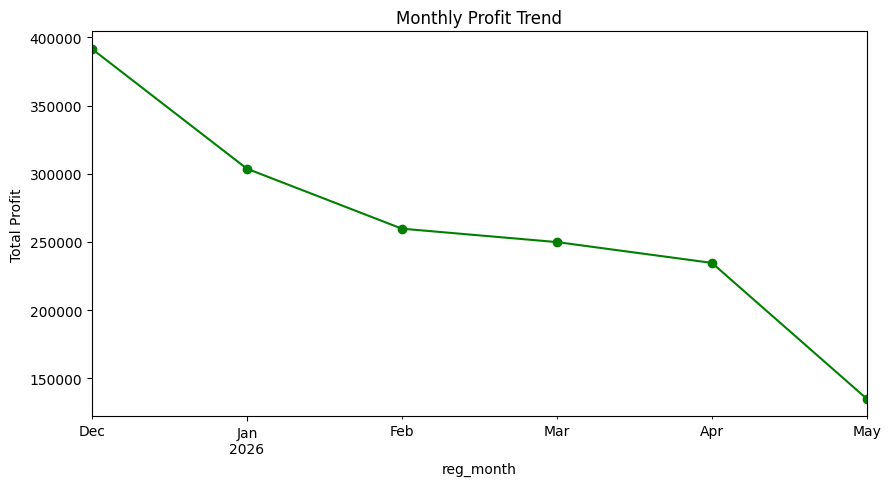

In [322]:
monthly_profit = df.groupby("reg_month")["Job Profit"].sum()

monthly_profit.plot(marker="o", color="green", figsize=(10,5))
plt.title("Monthly Profit Trend")
plt.ylabel("Total Profit")
plt.show()

The monthly profit trend shows a clear decline after December, which represents the peak in profitability. This pattern closely follows the decrease in operational activity, indicating that profit is strongly linked to shipment volume. However, the sharp drop observed in later months also suggests that operational efficiency and cost factors may be affecting overall profitability.

## 2.2 Profit by Branch

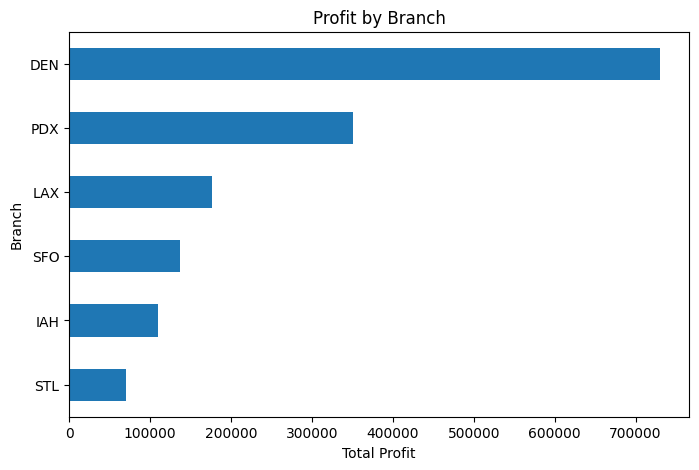

In [323]:
df.groupby("Branch")["Job Profit"].sum().sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Profit by Branch")
plt.xlabel("Total Profit")
plt.show()

The profit distribution by branch shows that Denver generates the highest profit by a large margin, followed by Portland. This aligns with the earlier observation that Denver also handles the highest operational volume, indicating a strong relationship between activity and profitability. However, this concentration suggests a dependency on a single branch, which may introduce operational and financial risk.

## 2.3 Revenue vs Profit

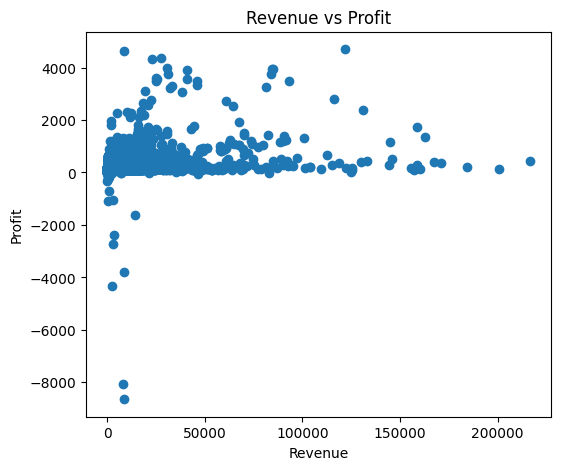

In [324]:
plt.figure(figsize=(6,5))
plt.scatter(df["Revenue"], df["Job Profit"])
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.show()

The scatter plot shows the relationship between revenue and profit. While there is a general positive trend, the relationship is relatively weak. Notably, several cases exhibit high revenue but low or even negative profit, indicating that revenue alone does not guarantee profitability. This suggests that cost management and operational efficiency play a critical role in financial performance.

## 2.4 Profit by Transport Type

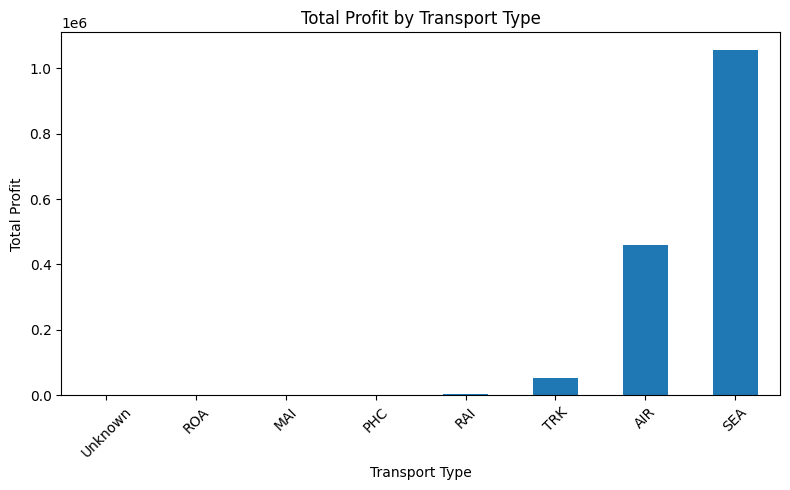

In [325]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

df.groupby("Transport Type")["Job Profit"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Total Profit by Transport Type")
plt.xlabel("Transport Type")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [326]:
df["Job Profit"].describe()

count    7635.000000
mean      206.210716
std       326.907884
min     -8642.950000
25%       107.050000
50%       150.000000
75%       243.845000
max      4699.270000
Name: Job Profit, dtype: float64

<Axes: xlabel='Job Profit'>

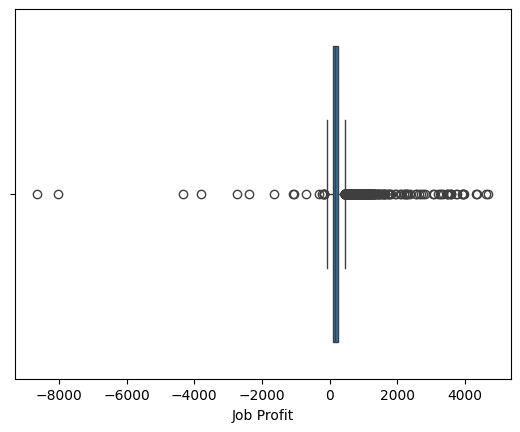

In [327]:
sns.boxplot(x=df["Job Profit"])

# 3. DELAY ANALYSIS

## 3.1 Delay Distribution

In [328]:
df["Delay"] = (df["Arrival ATA"] - df["Dest. ETA"]).dt.days

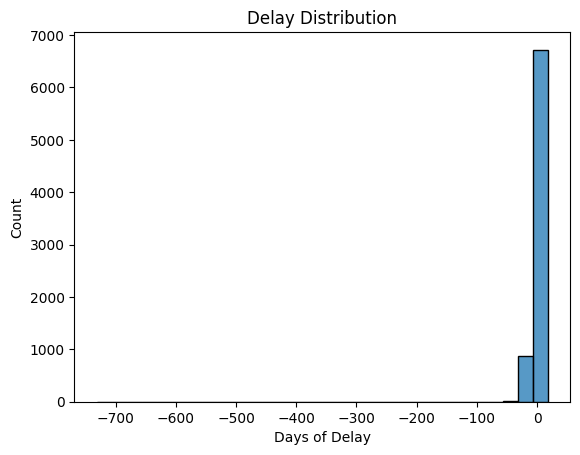

In [329]:
sns.histplot(df["Delay"], bins=30)
plt.title("Delay Distribution")
plt.xlabel("Days of Delay")
plt.show()

The delay distribution shows that most shipments are concentrated around zero, indicating that operations are generally on time. However, the presence of extreme negative outliers suggests potential data inconsistencies or anomalies. These values may need to be addressed before modeling to ensure accurate predictions.

## 3.2 Delay by Transport Type

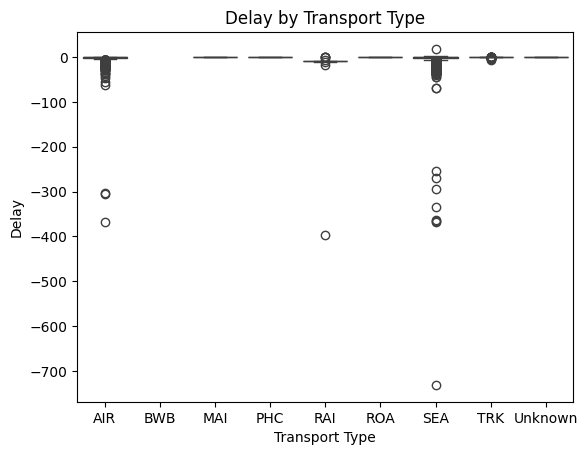

In [330]:
sns.boxplot(x="Transport Type", y="Delay", data=df)
plt.title("Delay by Transport Type")
plt.show()

The analysis of delay by transport type shows that most shipments across all modes are concentrated around zero delay. However, sea transport exhibits significantly higher variability and extreme outliers, indicating greater operational risk and inconsistency. In contrast, air transport appears more stable. These differences highlight the importance of transport type as a key factor in delay prediction.

## 3.3 Delay vs Profit

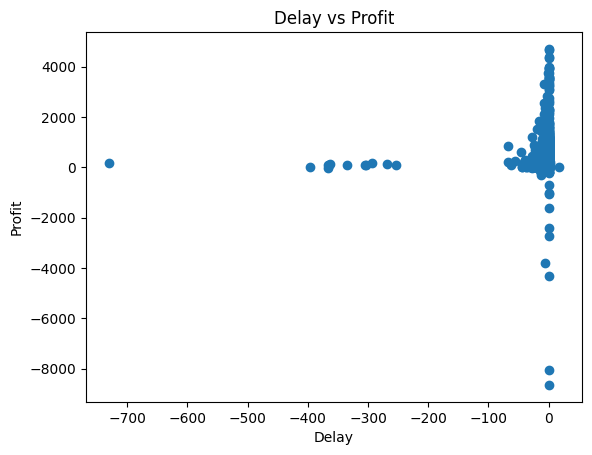

In [331]:
plt.scatter(df["Delay"], df["Job Profit"])
plt.title("Delay vs Profit")
plt.xlabel("Delay")
plt.ylabel("Profit")
plt.show()


The relationship between delay and profit shows no strong linear pattern. While most shipments are near zero delay, profitability varies widely, including both high profits and losses. This indicates that delay alone does not explain financial performance. The variability suggests that other factors, such as cost and operational efficiency, play a critical role. Additionally, the presence of extreme outliers highlights the need for further data treatment before modeling.

## Shipments with Delay

In [332]:
total_shipments = len(df)

delayed_shipments = (df["Delay"] > 0).sum()

print("Total shipments:", total_shipments)
print("Shipments with delay:", delayed_shipments)

Total shipments: 7635
Shipments with delay: 6


Only 0.08% of shipments experienced delays, indicating a highly imbalanced distribution. This limits the predictive value of delay modeling, as most observations correspond to on-time deliveries.

# Heatmap

In [333]:
numeric_cols = [
    "Invoice Headers",
    "Invoice Lines",
    "Weight",
    "Volume",
    "Packs",
    "Revenue",
    "Total Income",
    "Cost",
    "Total Expense",
    "Job Profit",
    "Container Count",
    "TEU"
]

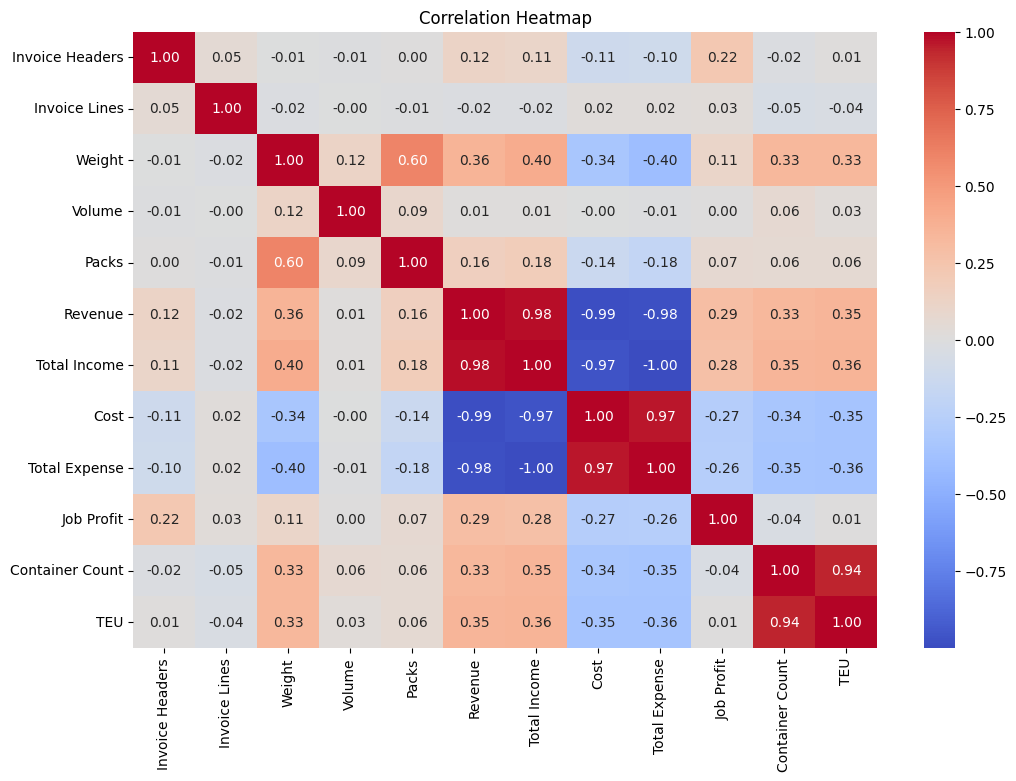

In [334]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


## Correlation Analysis

The correlation heatmap reveals strong relationships among financial variables, particularly between revenue and total income (≈0.98), as well as strong inverse correlations with cost and total expense (≈ -0.97 to -0.99). 

- This indicates a high level of redundancy among financial variables, as they capture closely related aspects of the same financial structure.

In contrast, job profit shows only moderate correlations with these variables (≈0.25–0.30), suggesting that profitability is not directly determined by a single financial metric. 

- This highlights that high revenue does not necessarily result in high profit, reinforcing the importance of efficiency rather than scale.

Additionally, shipment size variables such as weight, packs, and container count show moderate correlations with revenue (≈0.30–0.60), indicating that larger shipments tend to generate higher revenue, but not proportionally higher profitability.

- This suggests that shipment size alone is not a reliable indicator of profit.

### Key Insight

Profitability is not strongly correlated with any single variable, indicating that it is driven by a combination of factors rather than isolated inputs. This supports the use of machine learning models capable of capturing complex, non-linear relationships.

# Feature Engineering   

Feature engineering was conducted to transform raw operational data into meaningful predictors, focusing on temporal patterns, financial efficiency, shipment characteristics, and operational complexity

## Temporal Features

In [335]:
df["month"] = df["Dec. Registered"].dt.month

In [336]:
df["weekday"] = df["Dec. Registered"].dt.weekday

In [337]:
df["quarter"] = df["month"].apply(lambda x: (x - 1) // 3 + 1)

In [338]:
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [339]:
df[["Dec. Registered", "month"]].head(5)

,Dec. Registered,month
0,2025-12-01 15:13:00,12
1,2025-12-01 15:15:00,12
3,2025-12-01 15:18:00,12
4,2025-12-01 16:01:00,12
5,2025-12-01 16:07:00,12


Temporal features were created from the shipment registration date to capture seasonal and operational patterns. Variables such as month, weekday, quarter, and weekend indicators were used to reflect time-based variations that may influence shipment activity and profitability.

## Logistical Time Features

## Transit Time

In [340]:
df["transit_time"] = (df["Arrival ATA"] - df["Origin ETD"]).dt.days

In [341]:
df[["Origin ETD", "Arrival ATA", "transit_time"]].head(5)

,Origin ETD,Arrival ATA,transit_time
0,2025-11-27,2025-11-27,0
1,2025-11-26,2025-11-29,3
3,2025-10-04,2025-12-01,58
4,2025-11-19,2025-12-02,13
5,2025-10-15,2025-11-30,46


Transit time was calculated as the number of days between the estimated departure date and the actual arrival date, representing the total duration of the shipment process. This feature captures transportation efficiency and is expected to influence profitability, as longer transit times may increase operational costs and reduce margins.

## Handling Time


In [342]:
df["handling_time"] = (df["Load ATD"] - df["Origin ETD"]).dt.days

In [343]:
df[["Origin ETD", "Load ATD", "handling_time"]].head(5)

,Origin ETD,Load ATD,handling_time
0,2025-11-27,2025-11-27,0
1,2025-11-26,2025-11-26,0
3,2025-10-04,2025-10-04,0
4,2025-11-19,2025-11-19,0
5,2025-10-15,2025-10-15,0


Handling time was defined as the number of days between the estimated departure date and the actual loading date. This feature captures internal operational efficiency, including preparation, documentation, and loading processes. Higher handling times indicate potential inefficiencies in shipment processing, which may increase operational costs and negatively impact profitability.

In [344]:
df["handling_time"] = df["handling_time"].clip(lower=0)

In [345]:
df["handling_time"].value_counts()

handling_time
0       7072
1        186
2        100
3         55
4         28
5         27
7         22
8         20
13        12
6          9
10         9
11         9
9          7
16         7
14         6
20         6
365        6
31         5
28         4
27         4
18         4
19         3
29         3
12         2
15         2
23         2
17         2
30         2
22         1
86         1
47         1
49         1
44         1
379        1
33         1
39         1
2192       1
40         1
366        1
24         1
56         1
37         1
303        1
48         1
41         1
1096       1
367        1
21         1
89         1
Name: count, dtype: int64

The handling time feature exhibited low variability, with more than 90% of the observations equal to zero, indicating that most shipments were processed on the same day. 

## Total Process Time

In [346]:
df["total_process_time"] = (df["Arrival ATA"] - df["Job Opened"]).dt.days

In [347]:
df["total_process_time"] = df["total_process_time"].clip(lower=0)

In [348]:
df[["Job Opened", "Arrival ATA", "total_process_time"]].head(5)

,Job Opened,Arrival ATA,total_process_time
0,2025-12-01 15:13:00,2025-11-27,0
1,2025-12-01 15:15:00,2025-11-29,0
3,2025-12-01 15:18:00,2025-12-01,0
4,2025-12-01 16:01:00,2025-12-02,0
5,2025-12-01 16:07:00,2025-11-30,0


Total process time was calculated as the number of days between job creation and final delivery. This feature captures the complete duration of the shipment lifecycle, including preparation, handling, and transportation stages.

## Financial Features

In [349]:
df["profit_margin"] = df["Job Profit"] / (df["Revenue"] + 1)

In [350]:
df["cost_ratio"] = df["Cost"] / (df["Revenue"] + 1)

In [351]:
df["expense_ratio"] = df["Total Expense"] / (df["Total Income"] + 1)

In [352]:
df[["profit_margin", "cost_ratio", "expense_ratio"]].describe()

,profit_margin,cost_ratio,expense_ratio
count,7635.000000,7635.000000,7635.000000
mean,0.311763,-0.544091,-0.691676
std,0.355879,0.424565,0.413046
min,-2.389150,-3.727088,-4.161983
25%,0.013876,-0.957541,-0.976895
50%,0.152517,-0.626962,-0.851319
75%,0.547398,-0.065894,-0.434501
max,1.002106,0.079122,0.000047


Financial ratio features were engineered to capture operational efficiency and cost structure. These include cost ratio and expense ratio, which represent the proportion of costs and expenses relative to revenue and income.
These features provide a more meaningful representation of profitability drivers compared to absolute monetary values.
The profit margin variable was initially considered but excluded from modeling due to its direct dependency on the target variable, which could introduce data leakage and artificially inflate model performance.

## Shipment Characteristics

In [353]:

df["weight_to_volume"] = df["Weight"] / (df["Volume"] + 1)


In [354]:
df["revenue_per_weight"] = df["Revenue"] / (df["Weight"] + 1)

In [355]:
df["revenue_per_volume"] = df["Revenue"] / (df["Volume"] + 1)

In [356]:
df["containers_efficiency"] = df["Revenue"] / (df["Container Count"] + 1)

Additional features were engineered to capture shipment characteristics and operational efficiency. These include ratios such as weight-to-volume, revenue per weight, revenue per volume, and revenue per container.
These variables provide insight into shipment density, value distribution, and container utilization, which are important factors in determining operational costs and profitability.

## Target Variable

In [357]:
df["Profit_Flag"] = (df["Job Profit"] > 0).astype(int)

In [358]:
df["Profit_Flag"].value_counts()

Profit_Flag
1    6714
0     921
Name: count, dtype: int64

I am going to balance it.

In [359]:
!{sys.executable} -m pip install scikit-learn



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [360]:
from sklearn.ensemble import RandomForestClassifier

In [361]:
RandomForestClassifier(class_weight="balanced")

,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fa

Several financial ratios were engineered, but ultimately excluded from the final model due to their direct relationship with the target variable, which could introduce data leakage.

# Final Dataset

In [362]:
num_features = [
    "month", "weekday", "quarter", "is_weekend",
    "Weight",
    "Volume",
    "Packs",
    "Container Count",
    "TEU",
    "Invoice Lines",
    "Invoice Headers",
    "transit_time",
    "total_process_time",
    "weight_to_volume"
]



In [363]:

cat_features = [
    "Transport Type",
    "Branch",
    "Origin Port",
    "Final Destination"
]



In [364]:

X = df[num_features + cat_features]
y = df["Profit_Flag"]


In [365]:
X = pd.get_dummies(X, drop_first=True)

## Train/Test Split

In [366]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# MODELING

## Random Forest

In [367]:

model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)


,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fa

In [368]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [369]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9207596594629993
Precision: 0.9541818181818181
Recall: 0.9576642335766423
ROC-AUC: 0.9008391835975639

Confusion Matrix:
[[  94   63]
 [  58 1312]]


The model is highly effective at identifying both profitable and non-profitable shipments, with very low misclassification rates.

## Feature importance

In [370]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

month                 0.118061
quarter               0.098732
Packs                 0.073560
total_process_time    0.071253
Weight                0.061209
weight_to_volume      0.060422
Invoice Lines         0.056745
transit_time          0.049227
Invoice Headers       0.047219
weekday               0.031828
dtype: float64

## Feature Importance Analysis

The feature importance results indicate that temporal variables play a significant role in predicting profitability. In particular, month and quarter are the most important features, suggesting that seasonality has a strong impact on shipment performance.
Shipment structure and complexity features, such as invoice lines, packs, weight, and weight-to-volume ratio, also contribute meaningfully to the model. This indicates that the physical characteristics and operational complexity of shipments are key drivers of profitability.
Operational time variables, including total process time and transit time, have a moderate impact, suggesting that efficiency in shipment handling and duration influences outcomes, though not as strongly as structural or temporal factors.
Overall, no single variable dominates the model. Instead, profitability is explained through a combination of temporal patterns, shipment characteristics, and operational efficiency, highlighting the importance of interactions between features.



## Logistic Regression

In [371]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


In [372]:

lr = LogisticRegression(max_iter=1000)


In [373]:
X_train.isna().sum().sort_values(ascending=False).head(10)

month              0
weekday            0
quarter            0
is_weekend         0
Weight             0
Volume             0
Packs              0
Container Count    0
TEU                0
Invoice Lines      0
dtype: int64

In [374]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


In [375]:
lr.fit(X_train, y_train)

c:\Users\tatiana.palacios\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [376]:

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]


In [377]:

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression
Accuracy: 0.8906352324819908
Precision: 0.8980807412309728
Recall: 0.9905109489051095
ROC-AUC: 0.6306685573480868


The model achieved strong performance, with high accuracy, precision, recall, and ROC-AUC values.

## XGBoost

In [378]:

import sys
!{sys.executable} -m pip install xgboost



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [379]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


In [380]:

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)


In [381]:
xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [382]:

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]


In [383]:

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBoost
Accuracy: 0.9299279633267845
Precision: 0.9513938527519656
Recall: 0.9715328467153285
ROC-AUC: 0.9047910177135152


The model achieved very similar performance to Random Forest, confirming that the predictive patterns are consistent across different algorithms.

## Results:

In [384]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.890635  0.630669
1        Random Forest  0.920760  0.900839
2              XGBoost  0.929928  0.904791


The strong performance gap between Logistic Regression and the ensemble models suggests that profitability is driven by non-linear relationships and interactions between variables, rather than simple linear patterns. The similar performance of Random Forest and XGBoost indicates that the predictive signal in the data is stable and not dependent on a specific model.